<h1 style="text-align: center;font-size: 40px;">Cataract Prediction using VGG19</h1>

---

<h3>Dataset Information:</h3>
Ocular Disease Intelligent Recognition (ODIR) is a structured ophthalmic database of 5,000 patients with age, color fundus photographs from left and right eyes and doctors' diagnostic keywords.
We classify images into two categories:
<ul>
  <li><b>Normal</b> – healthy fundus images</li>
  <li><b>Cataract</b> – images diagnosed with cataract</li>
</ul>

In [1]:
# Step 1: Download dataset using KaggleHub
import kagglehub
path = kagglehub.dataset_download('andrewmvd/ocular-disease-recognition-odir5k')
print('Path to dataset files:', path)

Path to dataset files: /kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k


In [2]:
# Step 2: Install required libraries
!pip install tensorflow scikit-learn

In [3]:
# Step 3: Import necessary libraries
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

2026-05-03 07:49:31.122451: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777794571.329985      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777794571.390664      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777794571.886426      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777794571.886465      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777794571.886467      57 computation_placer.cc:177] computation placer alr

In [4]:
# Step 4: Define dataset paths
csv_path  = os.path.join(path, 'full_df.csv')
image_dir = os.path.join(path, 'preprocessed_images')

df = pd.read_csv(csv_path)
df.head(3)

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O,filepath,labels,target,filename
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0_right.jpg
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",1_right.jpg
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",2_right.jpg


In [5]:
# Step 5: Extract Cataract & Normal image paths
def has_cataract(text):
    return 1 if 'cataract' in str(text).lower() else 0

df['left_cataract']  = df['Left-Diagnostic Keywords'].apply(has_cataract)
df['right_cataract'] = df['Right-Diagnostic Keywords'].apply(has_cataract)

left_cataract   = df.loc[(df.C == 1) & (df.left_cataract  == 1)]['Left-Fundus'].values
right_cataract  = df.loc[(df.C == 1) & (df.right_cataract == 1)]['Right-Fundus'].values
cataract_images = np.concatenate((left_cataract, right_cataract), axis=0)

left_normal   = df.loc[(df.C == 0) & (df['Left-Diagnostic Keywords']  == 'normal fundus')]['Left-Fundus'].sample(250, random_state=42).values
right_normal  = df.loc[(df.C == 0) & (df['Right-Diagnostic Keywords'] == 'normal fundus')]['Right-Fundus'].sample(250, random_state=42).values
normal_images = np.concatenate((left_normal, right_normal), axis=0)

print(f'Cataract images : {len(cataract_images)}')
print(f'Normal images   : {len(normal_images)}')

Cataract images : 594
Normal images   : 500


In [6]:
# Step 6: Build DataFrame
image_paths = (
    [os.path.join(image_dir, img) for img in cataract_images] +
    [os.path.join(image_dir, img) for img in normal_images]
)
labels = ['CATARACT'] * len(cataract_images) + ['NORMAL'] * len(normal_images)

data_df = pd.DataFrame({'filename': image_paths, 'class': labels})
# CORRECT - use floats
data_df['label'] = data_df['class'].map({'NORMAL': 0.0, 'CATARACT': 1.0})

print(data_df['class'].value_counts())
data_df.head()

class
CATARACT    594
NORMAL      500
Name: count, dtype: int64


,filename,class,label
0,/kaggle/input/datasets/andrewmvd/ocular-diseas...,CATARACT,1.0
1,/kaggle/input/datasets/andrewmvd/ocular-diseas...,CATARACT,1.0
2,/kaggle/input/datasets/andrewmvd/ocular-diseas...,CATARACT,1.0
3,/kaggle/input/datasets/andrewmvd/ocular-diseas...,CATARACT,1.0
4,/kaggle/input/datasets/andrewmvd/ocular-diseas...,CATARACT,1.0


<h3>Sample Images from Dataset</h3>

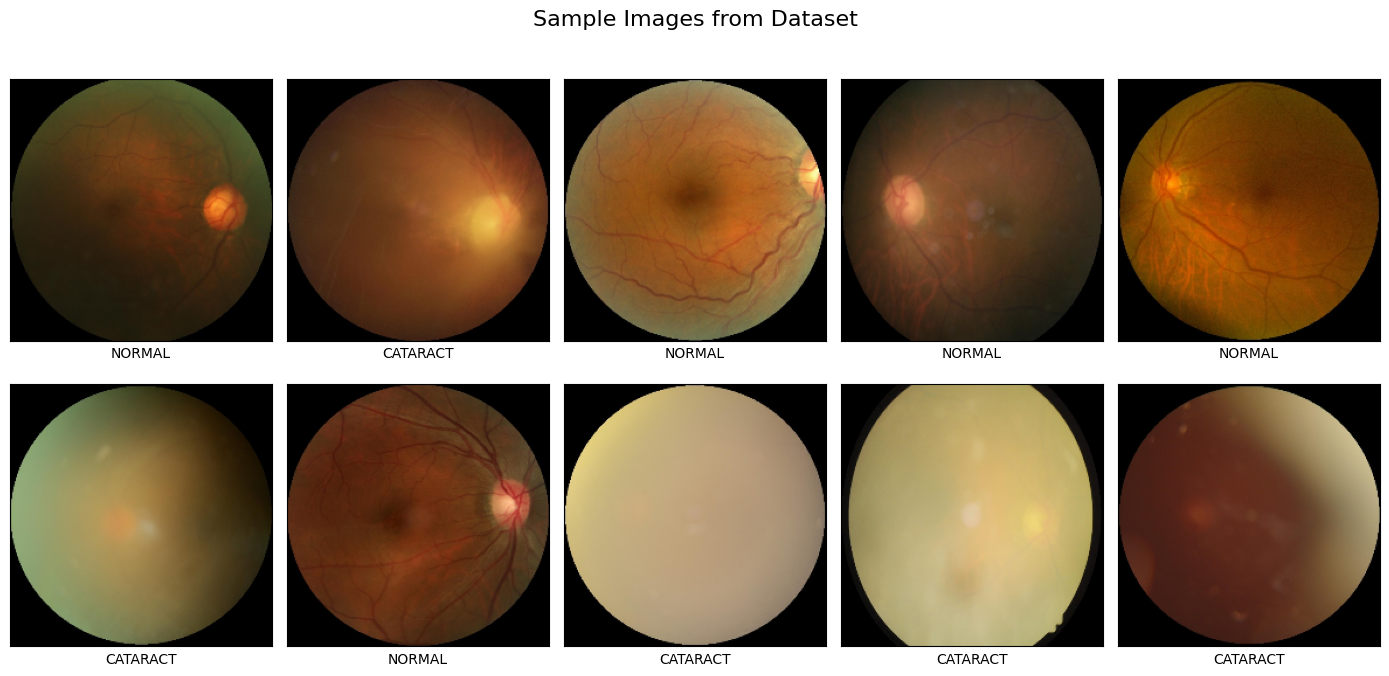

In [7]:
# Step 7: Visualise sample images from dataset
plt.figure(figsize=(14, 7))
sample_rows = data_df.sample(10, random_state=1).reset_index(drop=True)
for i, row in sample_rows.iterrows():
    image = cv2.imread(row['filename'])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (224, 224))
    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.xlabel(row['class'])
    plt.xticks([]); plt.yticks([])
plt.suptitle('Sample Images from Dataset', fontsize=16)
plt.tight_layout()
plt.show()

In [8]:
# Step 8: Train / Validation split
train_df, val_df = train_test_split(
    data_df, test_size=0.2, stratify=data_df['label'], random_state=42
)
print(f'Train size: {len(train_df)} | Val size: {len(val_df)}')

Train size: 875 | Val size: 219


In [9]:
# Step 9: Data generators with VGG19 preprocessing
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.vgg19.preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.vgg19.preprocess_input
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df, x_col='filename', y_col='label',
    target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode='raw'
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df, x_col='filename', y_col='label',
    target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode='raw', shuffle=False
)

Found 872 validated image filenames.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 3 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(


Found 216 validated image filenames.


In [10]:
# Step 10: Build VGG19 model
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

I0000 00:00:1777794598.519781      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777794598.525851      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 20,550,721 (78.39 MB)

 Trainable params: 526,337 (2.01 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [11]:
# Step 11: Callbacks
checkpoint = ModelCheckpoint(
    'vgg19_cataract_best.h5', monitor='val_accuracy',
    verbose=1, save_best_only=True, mode='max'
)
earlystop = EarlyStopping(
    monitor='val_accuracy', patience=5, verbose=1, mode='max'
)

In [12]:
# Step 12: Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=15,
    validation_data=val_generator,
    validation_steps=len(val_generator),
    callbacks=[checkpoint, earlystop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


I0000 00:00:1777794603.696129     141 service.cc:152] XLA service 0x7a7308004e70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777794603.696176     141 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777794603.696182     141 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777794604.280096     141 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/28 ━━━━━━━━━━━━━━━━━━━━ 6:30 14s/step - accuracy: 0.3750 - loss: 2.0084

I0000 00:00:1777794616.235478     141 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.6554 - loss: 0.8183
Epoch 1: val_accuracy improved from -inf to 0.92593, saving model to vgg19_cataract_best.h5


28/28 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.6611 - loss: 0.8051 - val_accuracy: 0.9259 - val_loss: 0.2113
Epoch 2/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.9290 - loss: 0.1925
Epoch 2: val_accuracy did not improve from 0.92593
28/28 ━━━━━━━━━━━━━━━━━━━━ 13s 457ms/step - accuracy: 0.9291 - loss: 0.1923 - val_accuracy: 0.9259 - val_loss: 0.1825
Epoch 3/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.9251 - loss: 0.1877
Epoch 3: val_accuracy did not improve from 0.92593
28/28 ━━━━━━━━━━━━━━━━━━━━ 13s 454ms/step - accuracy: 0.9258 - loss: 0.1867 - val_accuracy: 0.9213 - val_loss: 0.2005
Epoch 4/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.9381 - loss: 0.1772
Epoch 4: val_accuracy improved from 0.92593 to 0.93519, saving model to vgg19_cataract_best.h5


28/28 ━━━━━━━━━━━━━━━━━━━━ 13s 464ms/step - accuracy: 0.9385 - loss: 0.1759 - val_accuracy: 0.9352 - val_loss: 0.1651
Epoch 5/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.9444 - loss: 0.1618
Epoch 5: val_accuracy improved from 0.93519 to 0.93981, saving model to vgg19_cataract_best.h5


28/28 ━━━━━━━━━━━━━━━━━━━━ 13s 467ms/step - accuracy: 0.9448 - loss: 0.1609 - val_accuracy: 0.9398 - val_loss: 0.1656
Epoch 6/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.9451 - loss: 0.1710
Epoch 6: val_accuracy improved from 0.93981 to 0.94444, saving model to vgg19_cataract_best.h5


28/28 ━━━━━━━━━━━━━━━━━━━━ 13s 455ms/step - accuracy: 0.9452 - loss: 0.1697 - val_accuracy: 0.9444 - val_loss: 0.1617
Epoch 7/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.9668 - loss: 0.0933
Epoch 7: val_accuracy did not improve from 0.94444
28/28 ━━━━━━━━━━━━━━━━━━━━ 13s 451ms/step - accuracy: 0.9665 - loss: 0.0942 - val_accuracy: 0.9352 - val_loss: 0.1871
Epoch 8/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.9402 - loss: 0.1406
Epoch 8: val_accuracy did not improve from 0.94444
28/28 ━━━━━━━━━━━━━━━━━━━━ 13s 468ms/step - accuracy: 0.9404 - loss: 0.1405 - val_accuracy: 0.9352 - val_loss: 0.1604
Epoch 9/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.9643 - loss: 0.0854
Epoch 9: val_accuracy did not improve from 0.94444
28/28 ━━━━━━━━━━━━━━━━━━━━ 13s 468ms/step - accuracy: 0.9639 - loss: 0.0864 - val_accuracy: 0.9352 - val_loss: 0.1979
Epoch 10/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.9663 - loss: 0.1042
Epoch 10: val_accuracy did not

<h3>Learning Curve</h3>

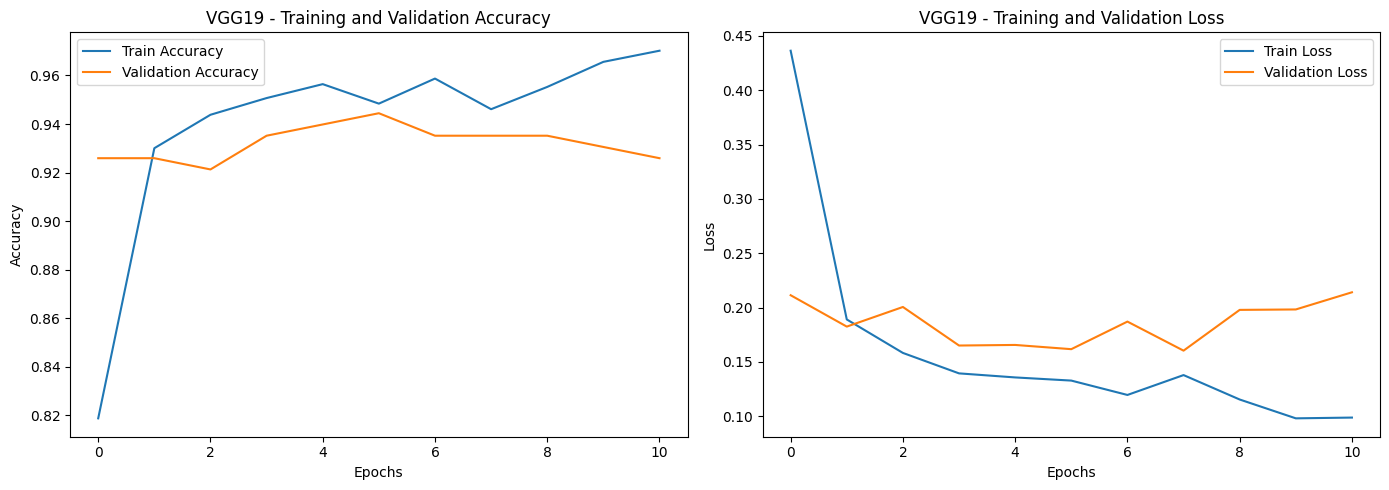

In [13]:
# Step 13: Plot training history
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('VGG19 - Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('VGG19 - Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Separate Accuracy & Loss Curves

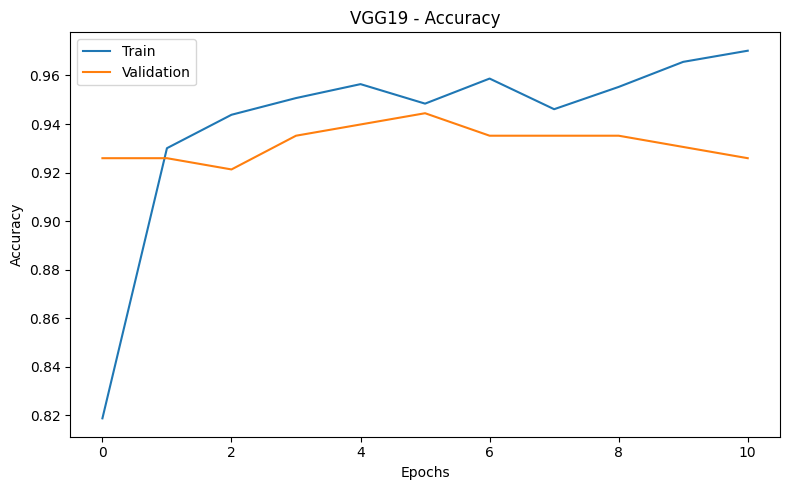

In [14]:
# Accuracy Curve (Train vs Validation)
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'],     label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('VGG19 - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

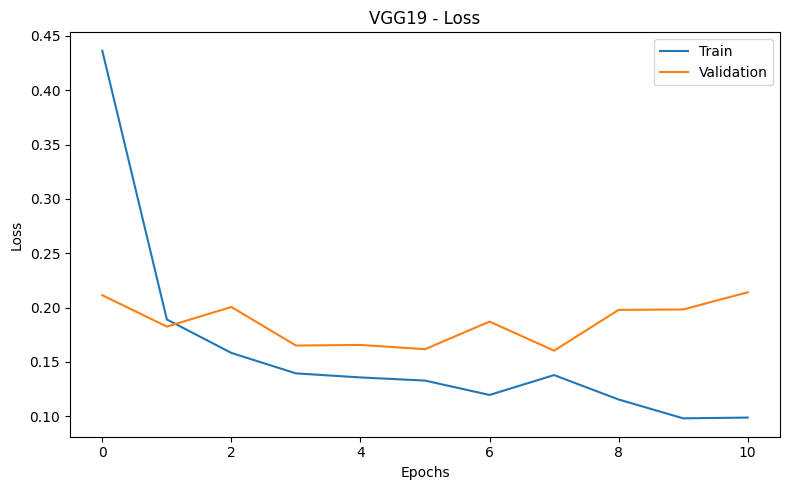

In [15]:
# Loss Curve (Train vs Validation)
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'],     label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('VGG19 - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# Step 14: Generate predictions
val_generator.reset()
y_pred_prob = model.predict(val_generator)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = val_generator.labels.astype(int)

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 340ms/step


<h3>Confusion Matrix</h3>

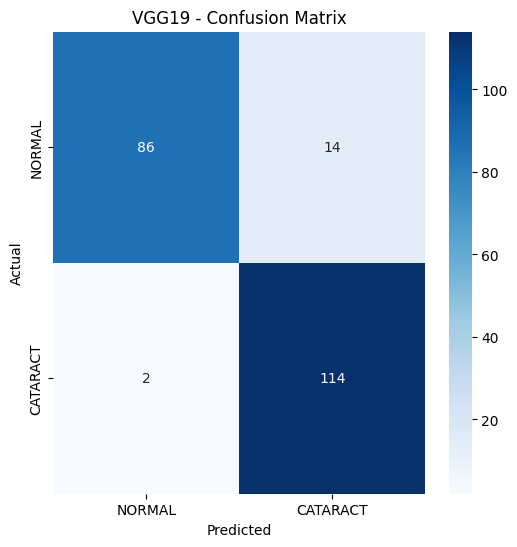

In [17]:
# Step 15: Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'CATARACT'],
            yticklabels=['NORMAL', 'CATARACT'])
plt.title('VGG19 - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Confusion Matrix — Counts & Normalized

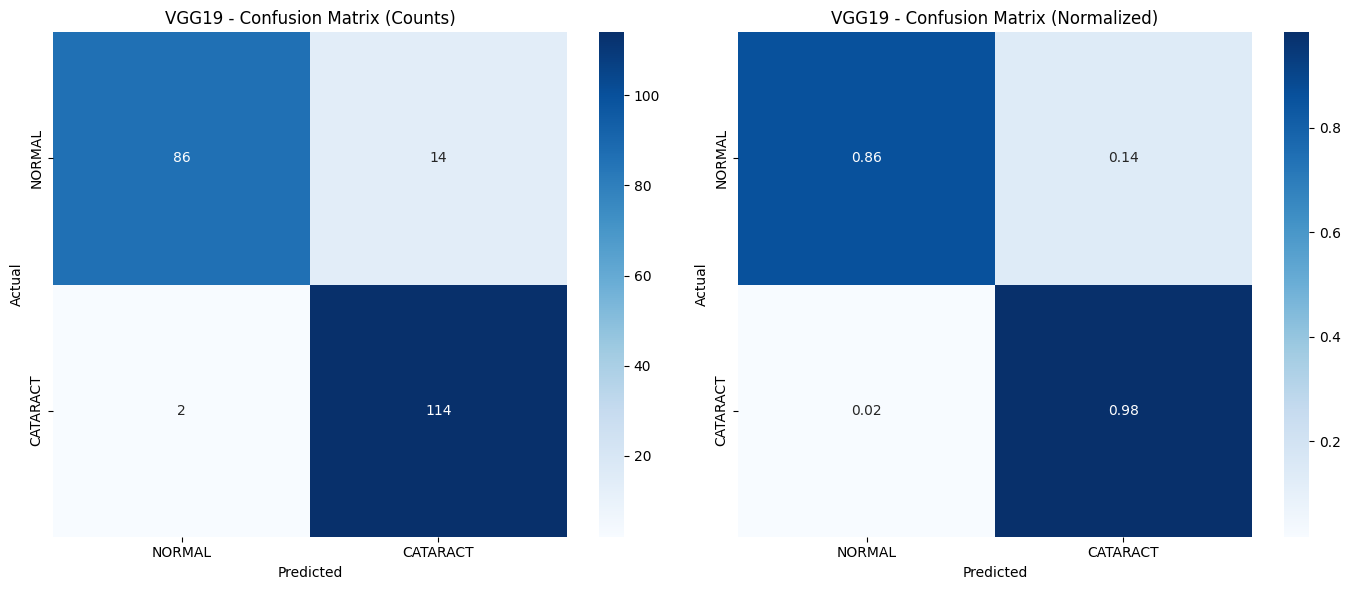

In [26]:
# Confusion Matrix - Counts & Normalized side by side
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'CATARACT'],
            yticklabels=['NORMAL', 'CATARACT'], ax=axes[0])
axes[0].set_title('VGG19 - Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['NORMAL', 'CATARACT'],
            yticklabels=['NORMAL', 'CATARACT'], ax=axes[1])
axes[1].set_title('VGG19 - Confusion Matrix (Normalized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [19]:
# Step 16: Classification report
print('\nVGG19 - Classification Report:')
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'CATARACT']))


VGG19 - Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.98      0.86      0.91       100
    CATARACT       0.89      0.98      0.93       116

    accuracy                           0.93       216
   macro avg       0.93      0.92      0.92       216
weighted avg       0.93      0.93      0.93       216



### ROC Curve

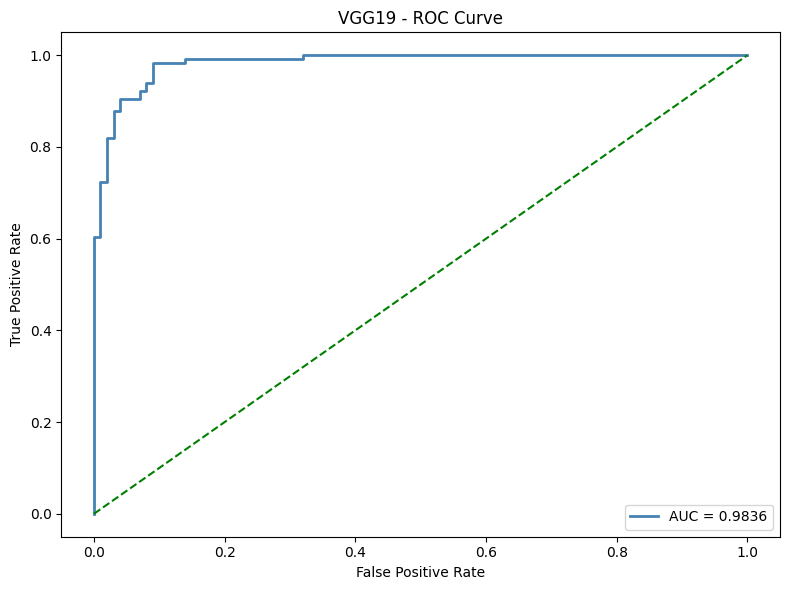

In [20]:
# ROC Curve
from sklearn.metrics import roc_curve, auc as sk_auc

fpr, tpr, _ = roc_curve(y_true, y_pred_prob.flatten())
roc_auc = sk_auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], color='green', linestyle='--')
plt.title('VGG19 - ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Error Analysis

<Figure size 800x600 with 0 Axes>

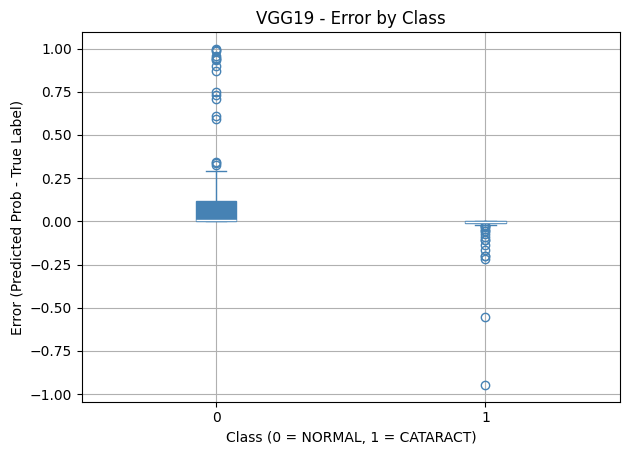

In [28]:
# Error by Class (box plot)
errors = y_pred_prob.flatten() - y_true
error_df = pd.DataFrame({'Error': errors, 'Class': y_true})

plt.figure(figsize=(8, 6))
error_df.boxplot(column='Error', by='Class', patch_artist=True,
                 boxprops=dict(facecolor='steelblue', color='steelblue'),
                 medianprops=dict(color='white'),
                 whiskerprops=dict(color='steelblue'),
                 capprops=dict(color='steelblue'),
                 flierprops=dict(markerfacecolor='none', markeredgecolor='steelblue'))
plt.title('VGG19 - Error by Class')
plt.suptitle('')
plt.xlabel('Class (0 = NORMAL, 1 = CATARACT)')
plt.ylabel('Error (Predicted Prob - True Label)')
plt.tight_layout()
plt.show()

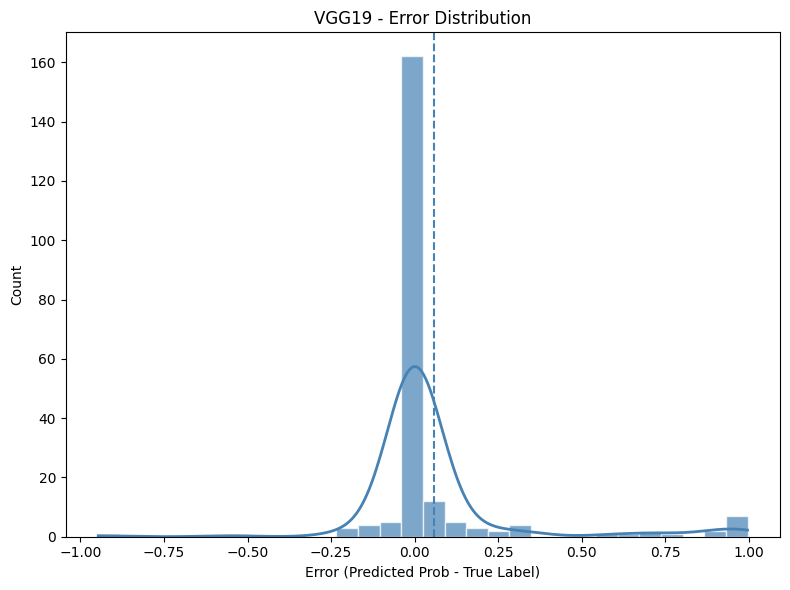

In [22]:
# Error Distribution
from scipy.stats import gaussian_kde

errors = y_pred_prob.flatten() - y_true

plt.figure(figsize=(8, 6))
plt.hist(errors, bins=30, alpha=0.7, color='steelblue', edgecolor='white')
kde_x = np.linspace(errors.min(), errors.max(), 300)
kde_y = gaussian_kde(errors)(kde_x) * len(errors) * (errors.max() - errors.min()) / 30
plt.plot(kde_x, kde_y, color='steelblue', lw=2)
plt.axvline(errors.mean(), color='steelblue', linestyle='--')
plt.title('VGG19 - Error Distribution')
plt.xlabel('Error (Predicted Prob - True Label)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Prediction Probability & Scatter

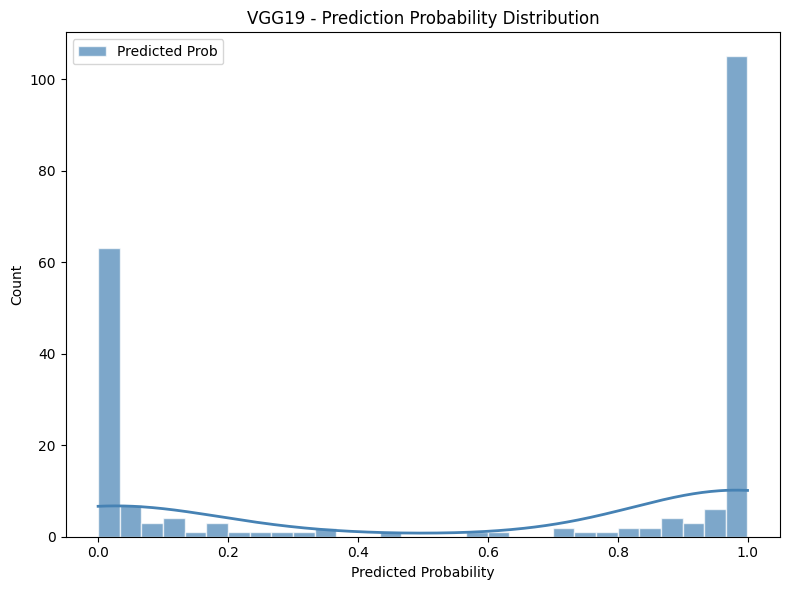

In [23]:
# Prediction Probability Distribution
from scipy.stats import gaussian_kde

probs = y_pred_prob.flatten()

plt.figure(figsize=(8, 6))
plt.hist(probs, bins=30, alpha=0.7, color='steelblue', edgecolor='white', label='Predicted Prob')
kde_x = np.linspace(0, 1, 300)
kde_y = gaussian_kde(probs)(kde_x) * len(probs) * (1 / 30)
plt.plot(kde_x, kde_y, color='steelblue', lw=2)
plt.title('VGG19 - Prediction Probability Distribution')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

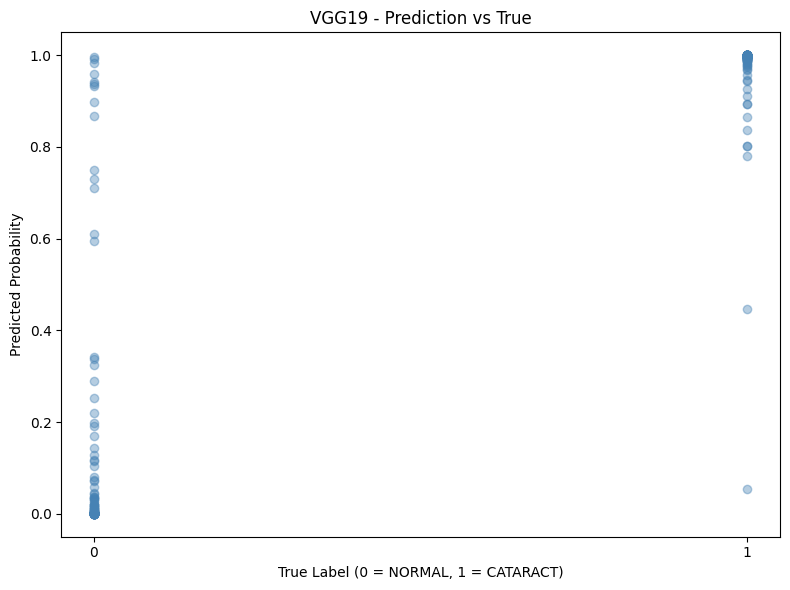

In [27]:
# Prediction vs True (scatter)
plt.figure(figsize=(8, 6))
plt.scatter(y_true, y_pred_prob.flatten(), alpha=0.4, color='steelblue')
plt.title('VGG19 - Prediction vs True')
plt.xlabel('True Label (0 = NORMAL, 1 = CATARACT)')
plt.ylabel('Predicted Probability')
plt.xticks([0, 1])
plt.tight_layout()
plt.show()

<h3>Prediction: Actual vs Predicted</h3>

[ WARN:0@212.628] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k/preprocessed_images/1456_right.jpg'): can't open/read file: check file path/integrity


error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


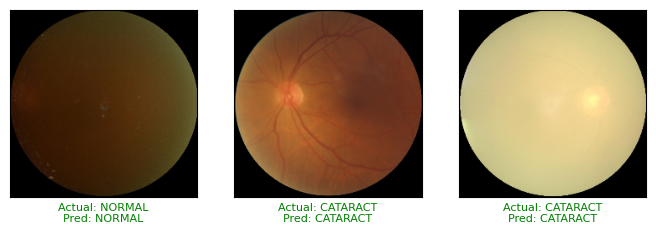

In [25]:
# Step 17: Visualise predictions on validation images
val_paths = val_df['filename'].reset_index(drop=True).values
class_map = {0: 'NORMAL', 1: 'CATARACT'}

plt.figure(figsize=(14, 7))
indices = random.sample(range(len(val_paths)), 10)
for plot_i, idx in enumerate(indices):
    image = cv2.imread(val_paths[idx])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (224, 224))

    actual    = class_map[y_true[idx]]
    predicted = class_map[y_pred[idx]]
    color     = 'green' if actual == predicted else 'red'

    plt.subplot(2, 5, plot_i + 1)
    plt.imshow(image)
    plt.xlabel(f'Actual: {actual}\nPred: {predicted}', color=color, fontsize=8)
    plt.xticks([]); plt.yticks([])

plt.suptitle('VGG19 - Actual vs Predicted (Green=Correct, Red=Wrong)', fontsize=13)
plt.tight_layout()
plt.show()